In [16]:
import os
import matplotlib.pyplot as plt
import numpy as np
from few.trajectory.ode.base import get_ode_properties
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.base import ODEBase

#rhs = SchwarzEccFlux()
#get_ode_properties(rhs)
#traj_model = EMRIInspiral(func=KerrEccEqFlux)

In [22]:
from multispline.spline import CubicSpline

notebook_dir = os.getcwd()
parent_dir=os.path.dirname(notebook_dir)
sample_points0PLT,sample_values0PLT=np.loadtxt(os.path.join(parent_dir,"data_for_FEW/Schwarzschild0PLTdata.csv"),delimiter=",")
sample_points2PLT,sample_values2PLT=np.loadtxt(os.path.join(parent_dir,"data_for_FEW/Schwarzschild2PLTdata.csv"),delimiter=",")
Fdeltar0PLT = CubicSpline(sample_points0PLT, sample_values0PLT)
Fdeltar2PLT = CubicSpline(sample_points2PLT, sample_values2PLT)

In [23]:
def Fr0PLT(r,eps):
    return -(eps**(3./5.)*Fdeltar0PLT(-(r-6.)/eps**(2./5.)))
def Fr2PLT(r,eps):
    return -(eps**(3./5.)*Fdeltar0PLT(-(r-6.)/eps**(2./5.))+eps*Fdeltar2PLT(-(r-6.)/eps**(2./5.)))
def Omega0PLT(p,eps):
    return eps**(2./5.) * (-(p-6.)/eps**(2./5.))/(24.*np.sqrt(6))
def Omega2PLT(p,eps):
    return eps**(2./5.) * (-(p-6.)/eps**(2./5.))/(24.*np.sqrt(6)) + eps**(4./5.) * (5.*(-(p-6.)/eps**(2./5.))**2.-2592.*Fdeltar0PLT((-(p-6.)/eps**(2./5.)))*Fdeltar0PLT.deriv(-(p-6.)/eps**(2./5.)))/(576.*np.sqrt(6.))

In [24]:
class Schwarzschild_Transition(ODEBase):
    @property
    def equatorial(self):
        return True

    @property
    def background(self):
        return "Schwarzschild"

    @property
    def flux_output_convention(self):
        return "pex"

    def cache_values_and_check_bounds(self,y):
        return True

    def evaluate_rhs(self, y):
        # guard against bad integration steps
        p, e, xI = y[:3]
        
        # Azimuthal frequency
        Omega_phi = 1/6.**(3./2.) + Omega2PLT(p,mu/M)

        # time derivatives
        pdot = Fr2PLT(p,mu/M)/(mu/M)

        edot = 0.0

        xIdot = 0.0

        Phi_phi_dot = Omega_phi
        Phi_theta_dot = 0.
        Phi_r_dot = 0.

        dydt = [pdot, edot, xIdot, Phi_phi_dot, Phi_theta_dot, Phi_r_dot]

        return dydt

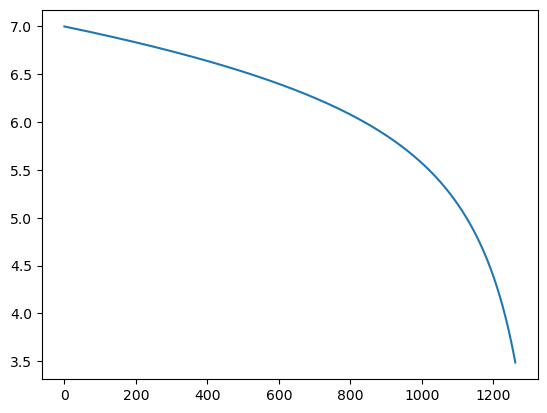

In [25]:
M = 1e6
mu = 1e5
p0 = 7.
e0 = 0.0
T = .00004

trans = EMRIInspiral(func=Schwarzschild_Transition)

traj = trans(M, mu, 0.0, p0, e0, 1.0, T=T, dt=1.0,upsample=True)
t,p,e,x,Phi_phi,Phi_theta,Phi_r=traj

plt.plot(t, p)
plt.show()

In [26]:
def Amp2PLT(p,eps):
    return eps*(np.loadtxt("/Users/lho/FastEMRIWaveforms/data_for_FEW/SchwarzschildAmp0PLTdata.csv",delimiter=",")[0]+1j*np.loadtxt("/Users/lho/FastEMRIWaveforms/data_for_FEW/SchwarzschildAmp0PLTdata.csv",delimiter=",")[1])+eps*(np.loadtxt("/Users/lho/FastEMRIWaveforms/data_for_FEW/SchwarzschildAmp0PLTdata.csv",delimiter=",")[2]+1j*np.loadtxt("/Users/lho/FastEMRIWaveforms/data_for_FEW/SchwarzschildAmp0PLTdata.csv",delimiter=",")[3])*(p-6)

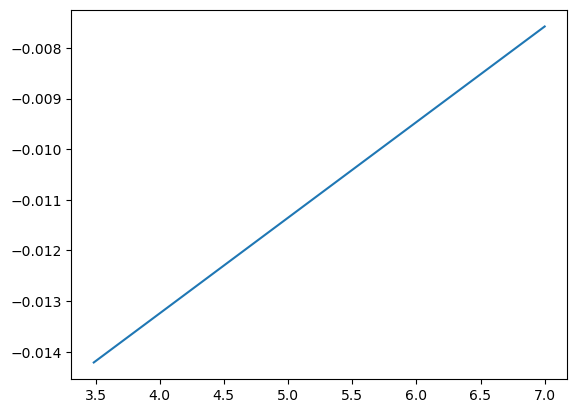

In [27]:
plt.plot(p,np.real(Amp2PLT(p,.01)))
plt.show()

In [28]:
WF2PLT=Amp2PLT(p,mu/M)*np.exp(-2j*Phi_phi)

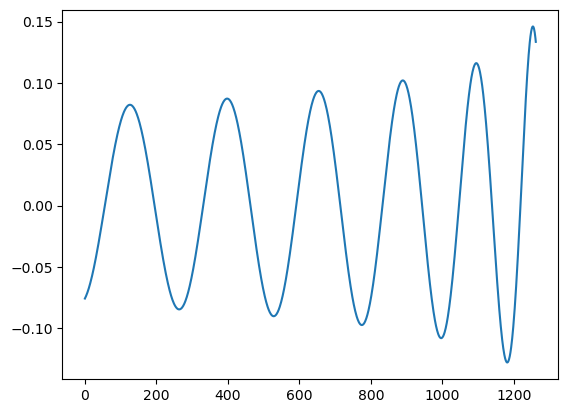

In [29]:
plt.plot(t,np.real(WF2PLT))
plt.show()